In [1]:
"""Code to plot RL training in thinking experiments."""
import _pickle as pickle
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from scipy.signal import savgol_filter

sns.set_palette("colorblind")
# plt.style.use("seaborn-v0_8-colorblind")
doc_width_pt = 452.9679

In [2]:
save_file = "./frozen_lake-ppo-ent_coef_0.02.pkl"
baseline_directory = "EXPS/baseline"
baseline_directory = ""
results_directory = "EXPS/debug_results-d_model_16-n_heads_1"
results_directory = "EXPS/debug_results-d_model_16-n_heads_1-n_thought_states_10"
results_directory = "EXPS/frozen_lake-ppo"
results_directory = "EXPS/frozen_lake-ppo-longer"
results_directory = "EXPS/frozen_lake-ppo-iterations_1000"
results_directory = "EXPS/frozen_lake-v4-ppo-iterations_2500"
results_directory = "EXPS/frozen_lake-v4-ppo-iterations_2500-ent_coef_0.02"
# results_directory = "EXPS/debug_results-d_model_16-n_heads_4"
# results_directory = "EXPS/debug_results-d_model_32-n_heads_4"
# results_directory = "EXPS/debug_results-d_model_64-n_heads_1"


if os.path.isfile(save_file):
    df_all, stats_dfs = pickle.load(open(save_file, "rb"))
else:
    data_list = []

    for curr_dir in [results_directory, baseline_directory]:
        if curr_dir.endswith(baseline_directory) and not os.path.isdir(curr_dir):
            continue
        for filename in os.listdir(curr_dir):

            if (
                ".npy" not in filename
                or "-thinkactions.npy" in filename
            ):
                continue

            base = "_".join(filename.split("_")[:-1])
            seed = re.findall(r"-?\d+", filename)[-1]

            x = np.load(os.path.join(curr_dir, filename))
            frac_thought_act_x = np.load(os.path.join(curr_dir, filename.replace(".npy", "-thinkactions.npy")))

            for t, (val, frac_thought_acts) in enumerate(zip(x, frac_thought_act_x)):
                data_list.append({"timepoint": t, "value": val, "frac_thought_acts": frac_thought_acts, "series": base, "run": seed})

    # Create DataFrame
    df_all = pd.DataFrame(data_list)
    df_all["series"] = df_all["series"].str.replace('test_thought_env-', '')

    stats_dfs = dict()
    for key in (
        "value",
        "frac_thought_acts",
    ):
        stats_df = (
            df_all.groupby(["series", "timepoint"])[key]
            .agg(["mean", "count", "std"])
            .reset_index()
        )

        stats_df["ci"] = 1.96 * stats_df["std"] / np.sqrt(stats_df["count"])
        stats_df["lower"] = stats_df["mean"] - stats_df["ci"]
        stats_df["upper"] = stats_df["mean"] + stats_df["ci"]

        # -----------------------------
        # 3. Savitzky–Golay smoothing helper
        # -----------------------------
        def smooth_series(x, window=21, poly=3):
            x = np.asarray(x)

            # adapt window to length
            w = min(window, len(x) if len(x) % 2 == 1 else len(x) - 1)
            w = max(w, poly + 2 + (poly + 2) % 2)  # ensure valid odd window

            return savgol_filter(x, window_length=w, polyorder=poly)

        # sort for stability
        stats_df = stats_df.sort_values(["series", "timepoint"])

        for col in ["mean", "lower", "upper"]:
            stats_df[f"{col}_smooth"] = (
                stats_df.groupby("series")[col]
                .transform(lambda x: smooth_series(x, window=21, poly=3))
            )
        stats_dfs[key] = stats_df

    pickle.dump(
        (df_all, stats_dfs),
        open(save_file, "wb")
    )

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1), use_golden_ratio=True):
    """
    Reference: https://jwalton.info/Matplotlib-latex-PGF/
    Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    if use_golden_ratio:
        # Golden ratio to set aesthetic figure height
        golden_ratio = (5**0.5 - 1) / 2

        # Figure height in inches
        fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    else:
        fig_height_in = fig_width_in * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


pgf_with_latex = {  # setup matplotlib to use latex for output
    "pgf.texsystem": "pdflatex",  # change this if using xetex or lautex
    "text.usetex": True,  # use LaTeX to write all text
    "font.family": "serif",
    "font.serif": [],  # blank entries should cause plots to inherit fonts from the document
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 10,  # LaTeX default is 10pt font.
    "font.size": 10,
    "legend.fontsize": 8,  # Make the legend/label fonts a little smaller
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
}

if save_file.startswith("/Users"):
    plt.rcParams.update(pgf_with_latex)

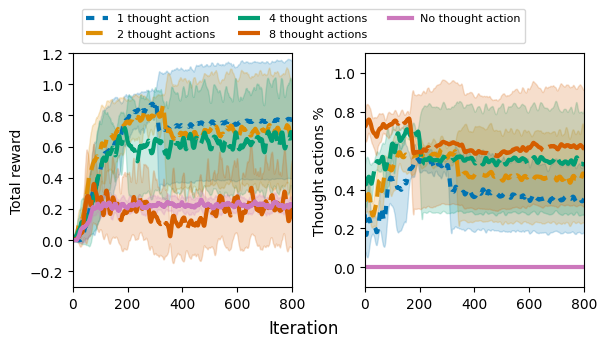

In [4]:
num_rows = 1
num_cols = 2
fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=set_size(doc_width_pt, 0.95, (num_rows, num_cols), use_golden_ratio=False),
    layout="constrained",
)

linestyle_map = {
    "no_thought_acts": "-",
    "n_thought_states_1-n_thought_acts_1": (0, (2, 2)),   # short dashes
    "n_thought_states_1-n_thought_acts_2": (0, (4, 2)),   # medium-short
    "n_thought_states_1-n_thought_acts_4": (0, (8, 2)),   # medium-long
    "n_thought_states_1-n_thought_acts_8": (0, (16, 2)),  # long dashes
}
label_map = {
    "no_thought_acts": "No thought action",
    "n_thought_states_1-n_thought_acts_1": "1 thought action",
    "n_thought_states_1-n_thought_acts_2": "2 thought actions",
    "n_thought_states_1-n_thought_acts_4": "4 thought actions",
    "n_thought_states_1-n_thought_acts_8": "8 thought actions",
}


palette = sns.color_palette(n_colors=stats_df["series"].nunique())
for ax_i, (key, stats_df) in enumerate(stats_dfs.items()):
    ax = axes[ax_i]
    for color, (series, group) in zip(
        palette,
        stats_df.groupby("series", sort=False),
    ):
        group = group.sort_values("timepoint")

        ax.plot(
            group["timepoint"],
            group["mean_smooth"],
            lw=3,
            color=color,
            label=label_map[series] if ax_i == 0 else "",
            linestyle=linestyle_map[series],
        )

        ax.fill_between(
            group["timepoint"],
            group["lower_smooth"],
            group["upper_smooth"],
            color=color,
            alpha=0.2,
        )

    if key == "frac_thought_acts":
        ax.set_ylabel("Thought actions %")
        ax.set_ylim(-0.1, 1.1)
    else:
        ax.set_ylabel("Total reward")
        ax.set_ylim(-0.3, 1.2)
    ax.set_xlim(0, 800)

fig.supxlabel("Iteration")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=3,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8", 
)

# fig.tight_layout()
# plt.subplots_adjust(bottom=0.25)
# plt.show()
plt.savefig("frozen_lake_v4-result.pdf", dpi=600, format="pdf", bbox_inches="tight")